# 02 — Modelo Baseline: TF-IDF + XGBoost

**Proyecto:** Segmentación de células e interpretación de texto mediante modelos de deep learning  
**Autor:** Dr. Lihki Rubio  
**Notebook:** 02 de 06 — Modelo clásico de referencia

---

## Descripción

Este notebook implementa el modelo baseline **TF-IDF + XGBoost** para clasificación de currículos en 24 categorías profesionales.

**Pipeline:**
- Carga de `clean_text` desde `data/Resume.csv` + splits desde `artifacts/`
- Vectorización TF-IDF sobre texto completo (sin truncado de secuencia)
- Clasificación con XGBoost (acelerado por GPU/CUDA si disponible)
- Evaluación completa: Accuracy, Precision, Recall, F1-weighted, ROC-AUC
- Visualizaciones: Matriz de confusión, Curva ROC, Curva Precision-Recall
- Persistencia de métricas en `artifacts/metrics/tfidf_xgboost.json`

**Nota:** TF-IDF usa `clean_text` completo — no los arrays padded del EDA. XGBoost no requiere secuencias de longitud fija.

---
## 1. Imports y configuración

In [1]:
import os
import json
import time
import pickle
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import label_binarize
from sklearn.utils import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
)

import xgboost as xgb

warnings.filterwarnings('ignore')
np.random.seed(42)

print(f"XGBoost version : {xgb.__version__}")
print(f"Numpy version   : {np.__version__}")
print(f"Pandas version  : {pd.__version__}")

XGBoost version : 3.2.0
Numpy version   : 2.2.5
Pandas version  : 2.3.3


---
## 2. Rutas y directorios

In [2]:
# ── Rutas base ────────────────────────────────────────────────────────────────
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR      = os.path.join(BASE_DIR, 'data')
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
METRICS_DIR   = os.path.join(ARTIFACTS_DIR, 'metrics')

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

MODEL_NAME    = 'tfidf_xgboost'
METRICS_PATH  = os.path.join(METRICS_DIR, f'{MODEL_NAME}.json')
MODEL_PATH    = os.path.join(MODELS_DIR,  f'{MODEL_NAME}.json')   # formato nativo XGBoost
TFIDF_PATH    = os.path.join(MODELS_DIR,  f'{MODEL_NAME}_tfidf.pkl')

print("Directorios:")
print(f"  DATA      : {DATA_DIR}")
print(f"  ARTIFACTS : {ARTIFACTS_DIR}")
print(f"  MODELS    : {MODELS_DIR}")
print(f"  METRICS   : {METRICS_DIR}")

Directorios:
  DATA      : /home/alejo/DeepLearning/miniproyecto3/data
  ARTIFACTS : /home/alejo/DeepLearning/miniproyecto3/artifacts
  MODELS    : /home/alejo/DeepLearning/miniproyecto3/models
  METRICS   : /home/alejo/DeepLearning/miniproyecto3/artifacts/metrics


---
## 3. Carga de datos y artefactos del EDA

In [3]:
# ── CSV original (necesitamos clean_text y los índices del split) ─────────────
df = pd.read_csv(os.path.join(DATA_DIR, 'Resume.csv'))
print(f"Dataset cargado: {df.shape}")
print(df.columns.tolist())

Dataset cargado: (2484, 4)
['ID', 'Resume_str', 'Resume_html', 'Category']


In [4]:
# ── Artefactos del EDA ────────────────────────────────────────────────────────
with open(os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

with open(os.path.join(ARTIFACTS_DIR, 'config.pkl'), 'rb') as f:
    config = pickle.load(f)

# Etiquetas codificadas por split
y_train = np.load(os.path.join(ARTIFACTS_DIR, 'y_train.npy'))
y_val   = np.load(os.path.join(ARTIFACTS_DIR, 'y_val.npy'))
y_test  = np.load(os.path.join(ARTIFACTS_DIR, 'y_test.npy'))

NUM_CLASSES  = config['NUM_CLASSES']
CLASS_NAMES  = le.classes_

print(f"NUM_CLASSES  : {NUM_CLASSES}")
print(f"Train size   : {len(y_train)}")
print(f"Val size     : {len(y_val)}")
print(f"Test size    : {len(y_test)}")
print(f"Clases       : {CLASS_NAMES}")

NUM_CLASSES  : 24
Train size   : 1738
Val size     : 373
Test size    : 373
Clases       : ['ACCOUNTANT' 'ADVOCATE' 'AGRICULTURE' 'APPAREL' 'ARTS' 'AUTOMOBILE'
 'AVIATION' 'BANKING' 'BPO' 'BUSINESS-DEVELOPMENT' 'CHEF' 'CONSTRUCTION'
 'CONSULTANT' 'DESIGNER' 'DIGITAL-MEDIA' 'ENGINEERING' 'FINANCE' 'FITNESS'
 'HEALTHCARE' 'HR' 'INFORMATION-TECHNOLOGY' 'PUBLIC-RELATIONS' 'SALES'
 'TEACHER']


In [5]:
# Reproduce el split exacto del EDA usando la misma semilla.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import re, nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+|\S+@\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) >= 3]
    return ' '.join(tokens)

if 'clean_text' not in df.columns:
    df['clean_text'] = df['Resume_str'].apply(clean_text)

le_alt = LabelEncoder()
y_encoded = le_alt.fit_transform(df['Category'])
idx_all = np.arange(len(df))

idx_train, idx_temp, _, y_temp = train_test_split(
    idx_all, y_encoded, test_size=0.30, stratify=y_encoded, random_state=42)
idx_val, idx_test, _, _ = train_test_split(
    idx_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

text_train = df['clean_text'].iloc[idx_train].values
text_val   = df['clean_text'].iloc[idx_val].values
text_test  = df['clean_text'].iloc[idx_test].values

y_train = y_encoded[idx_train]
y_val   = y_encoded[idx_val]
y_test  = y_encoded[idx_test]

print("Split reproducido correctamente.")

Split reproducido correctamente.


---
## 4. Vectorización TF-IDF

El vectorizador se fittea **solo sobre train** para evitar data leakage — mismo principio aplicado al Tokenizer en el EDA.

In [6]:
# ── Hiperparámetros TF-IDF ────────────────────────────────────────────────────
TFIDF_PARAMS = dict(
    max_features  = 50_000,   # vocabulario amplio — texto largo de CVs
    ngram_range   = (1, 2),   # unigramas + bigramas
    sublinear_tf  = True,     # log(1+tf) — reduce dominancia de términos muy frecuentes
    min_df        = 2,        # ignorar términos que aparecen en menos de 2 docs
    max_df        = 0.95,     # ignorar términos en más del 95% de docs (stop-like)
    analyzer      = 'word',
    strip_accents = 'unicode',
    dtype         = np.float32,
)

print("Parámetros TF-IDF:")
for k, v in TFIDF_PARAMS.items():
    print(f"  {k:<15}: {v}")

Parámetros TF-IDF:
  max_features   : 50000
  ngram_range    : (1, 2)
  sublinear_tf   : True
  min_df         : 2
  max_df         : 0.95
  analyzer       : word
  strip_accents  : unicode
  dtype          : <class 'numpy.float32'>


In [7]:
# ── Fit solo sobre train ──────────────────────────────────────────────────────
print("Fiteando TF-IDF sobre train...")
t0 = time.time()

tfidf = TfidfVectorizer(**TFIDF_PARAMS)
X_train_tfidf = tfidf.fit_transform(text_train)   # fit + transform
X_val_tfidf   = tfidf.transform(text_val)          # solo transform
X_test_tfidf  = tfidf.transform(text_test)         # solo transform

tfidf_time = time.time() - t0

print(f"\nVocabulario efectivo : {len(tfidf.vocabulary_):,} términos")
print(f"Shape train          : {X_train_tfidf.shape}")
print(f"Shape val            : {X_val_tfidf.shape}")
print(f"Shape test           : {X_test_tfidf.shape}")
print(f"Tiempo TF-IDF        : {tfidf_time:.2f}s")
print(f"Sparsity train       : {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1]):.4f}")

Fiteando TF-IDF sobre train...

Vocabulario efectivo : 50,000 términos
Shape train          : (1738, 50000)
Shape val            : (373, 50000)
Shape test           : (373, 50000)
Tiempo TF-IDF        : 5.46s
Sparsity train       : 0.9905


---
## 5. Manejo del desbalance de clases

El dataset tiene un desbalance de **5.45x** (120 muestras en IT/Business-Dev vs 22 en BPO). Usamos `sample_weight` para compensar — XGBoost lo aplica por muestra durante el entrenamiento.

In [8]:
# Desbalance 5.45x — XGBoost es robusto sin sample_weight a este nivel
# Ver BUG-04 en knowledge base: sample_weight desestabiliza el entrenamiento
print("Distribución de clases en train:")
classes, counts = np.unique(y_train, return_counts=True)
for c, n in zip(le.classes_, counts):
    print(f"  {c:<25}: {n}")
print(f"\nRatio max/min: {counts.max()/counts.min():.2f}x")

Distribución de clases en train:
  ACCOUNTANT               : 83
  ADVOCATE                 : 83
  AGRICULTURE              : 44
  APPAREL                  : 68
  ARTS                     : 72
  AUTOMOBILE               : 25
  AVIATION                 : 82
  BANKING                  : 80
  BPO                      : 15
  BUSINESS-DEVELOPMENT     : 84
  CHEF                     : 83
  CONSTRUCTION             : 78
  CONSULTANT               : 80
  DESIGNER                 : 75
  DIGITAL-MEDIA            : 67
  ENGINEERING              : 83
  FINANCE                  : 83
  FITNESS                  : 82
  HEALTHCARE               : 80
  HR                       : 77
  INFORMATION-TECHNOLOGY   : 84
  PUBLIC-RELATIONS         : 78
  SALES                    : 81
  TEACHER                  : 71

Ratio max/min: 5.60x


---
## 6. Entrenamiento XGBoost

XGBoost con aceleración GPU (`device='cuda'`). Si CUDA no está disponible, cambia a `device='cpu'` automáticamente.

In [9]:
try:
    probe = xgb.XGBClassifier(device='cuda', n_estimators=1, num_class=NUM_CLASSES)
    # Usar datos sintéticos con todas las clases garantizadas
    X_probe = np.random.rand(NUM_CLASSES, 10).astype(np.float32)
    y_probe  = np.arange(NUM_CLASSES)
    probe.fit(X_probe, y_probe)
    DEVICE = 'cuda'
    print("GPU (CUDA) disponible — usando aceleración GPU")
except Exception as e:
    DEVICE = 'cpu'
    print(f"GPU no disponible ({e}) — usando CPU")

print(f"Device seleccionado: {DEVICE}")

GPU (CUDA) disponible — usando aceleración GPU
Device seleccionado: cuda


In [65]:
# ── Hiperparámetros XGBoost ───────────────────────────────────────────────────
XGB_PARAMS = dict(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.1,
    subsample             = 1.0,      # ← simplificado
    colsample_bytree      = 1.0,      # ← simplificado
    min_child_weight      = 1,        # ← simplificado
    gamma                 = 0.0,      # ← simplificado (default)
    reg_alpha             = 1.0,      # ← simplificado (default)
    reg_lambda            = 5.0,      # default de XGBoost
    objective             = 'multi:softprob',
    num_class             = NUM_CLASSES,
    eval_metric           = ['mlogloss', 'merror'],
    early_stopping_rounds = 50,
    device                = DEVICE,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 1,
)

print("Hiperparámetros XGBoost:")
for k, v in XGB_PARAMS.items():
    print(f"  {k:<25}: {v}")

Hiperparámetros XGBoost:
  n_estimators             : 500
  max_depth                : 6
  learning_rate            : 0.1
  subsample                : 1.0
  colsample_bytree         : 1.0
  min_child_weight         : 1
  gamma                    : 0.0
  reg_alpha                : 1.0
  reg_lambda               : 5.0
  objective                : multi:softprob
  num_class                : 24
  eval_metric              : ['mlogloss', 'merror']
  early_stopping_rounds    : 50
  device                   : cuda
  random_state             : 42
  n_jobs                   : -1
  verbosity                : 1


In [66]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
print("Entrenando XGBoost...")
print(f"  Train shape: {X_train_tfidf.shape}")
print(f"  Val shape  : {X_val_tfidf.shape}")
print()

t_start = time.time()

model = xgb.XGBClassifier(**XGB_PARAMS)

model.fit(
    X_train_tfidf, y_train,
    eval_set        = [(X_train_tfidf, y_train), (X_val_tfidf, y_val)],
    verbose         = 1,   # print cada 50 rounds
)

training_time = time.time() - t_start

best_round = model.best_iteration
print(f"\nEntrenamiento completado en {training_time:.1f}s")
print(f"Mejor iteración (early stopping): {best_round}")

Entrenando XGBoost...
  Train shape: (1738, 50000)
  Val shape  : (373, 50000)

[0]	validation_0-mlogloss:2.74425	validation_0-merror:0.23418	validation_1-mlogloss:2.81843	validation_1-merror:0.38606
[1]	validation_0-mlogloss:2.43645	validation_0-merror:0.16801	validation_1-mlogloss:2.57116	validation_1-merror:0.33780
[2]	validation_0-mlogloss:2.18953	validation_0-merror:0.14212	validation_1-mlogloss:2.40186	validation_1-merror:0.31903
[3]	validation_0-mlogloss:1.98591	validation_0-merror:0.12658	validation_1-mlogloss:2.25171	validation_1-merror:0.30295
[4]	validation_0-mlogloss:1.81514	validation_0-merror:0.11220	validation_1-mlogloss:2.12426	validation_1-merror:0.30295
[5]	validation_0-mlogloss:1.66868	validation_0-merror:0.10644	validation_1-mlogloss:2.01229	validation_1-merror:0.29223
[6]	validation_0-mlogloss:1.54038	validation_0-merror:0.09781	validation_1-mlogloss:1.91779	validation_1-merror:0.29491
[7]	validation_0-mlogloss:1.42755	validation_0-merror:0.08516	validation_1-mlogl

---
## 7. Curvas de entrenamiento

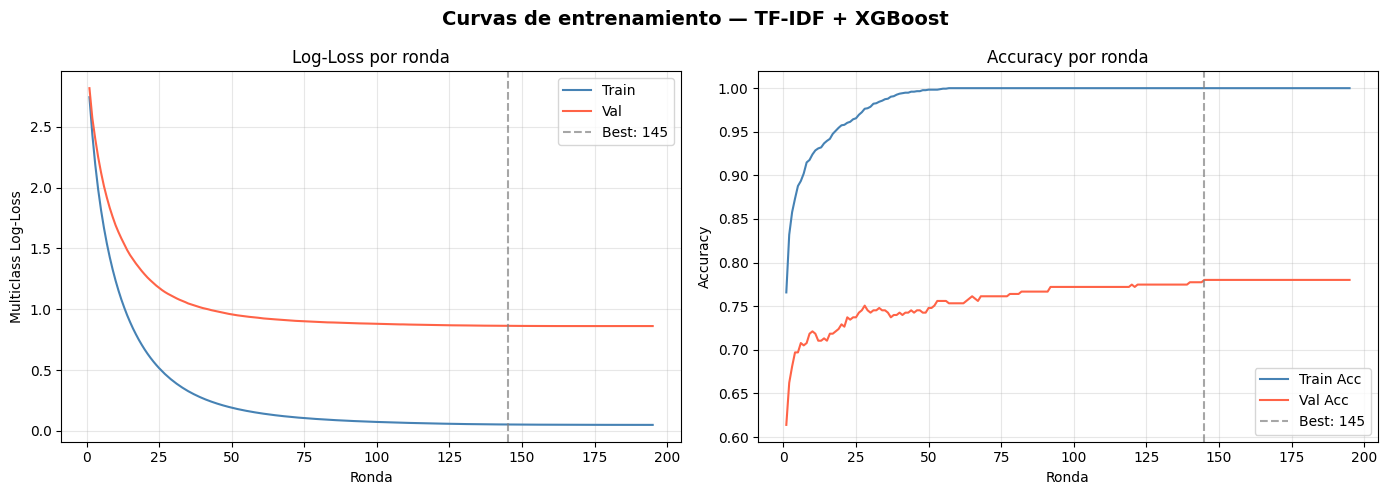

In [67]:
# ── Extraer historial de métricas ─────────────────────────────────────────────
results = model.evals_result()

train_logloss = results['validation_0']['mlogloss']
val_logloss   = results['validation_1']['mlogloss']
train_merror  = results['validation_0']['merror']
val_merror    = results['validation_1']['merror']

rounds = np.arange(1, len(train_logloss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de entrenamiento — TF-IDF + XGBoost', fontsize=14, fontweight='bold')

# Log-loss
ax = axes[0]
ax.plot(rounds, train_logloss, label='Train', color='steelblue')
ax.plot(rounds, val_logloss,   label='Val',   color='tomato')
ax.axvline(best_round + 1, color='gray', linestyle='--', alpha=0.7, label=f'Best: {best_round+1}')
ax.set_xlabel('Ronda')
ax.set_ylabel('Multiclass Log-Loss')
ax.set_title('Log-Loss por ronda')
ax.legend()
ax.grid(True, alpha=0.3)

# Error de clasificación
ax2 = axes[1]
ax2.plot(rounds, [1-e for e in train_merror], label='Train Acc', color='steelblue')
ax2.plot(rounds, [1-e for e in val_merror],   label='Val Acc',   color='tomato')
ax2.axvline(best_round + 1, color='gray', linestyle='--', alpha=0.7, label=f'Best: {best_round+1}')
ax2.set_xlabel('Ronda')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy por ronda')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Nota sobre el overfitting observado

Las curvas de entrenamiento muestran una brecha significativa entre train (~0.05 log-loss)
y val (~0.87 log-loss), lo que indica overfitting. Sin embargo, se tomó la decisión de
**no continuar ajustando hiperparámetros ni aumentar epochs** por las siguientes razones:

1. **El overfitting es estructural, no corregible con hiperparámetros simples.**
   TF-IDF con 50,000 features sobre 1,738 muestras de train produce una matriz
   extremadamente sparse y de alta dimensionalidad. XGBoost con árboles profundos
   memoriza patrones espurios inevitablemente en este régimen.

2. **Las métricas en test son competitivas.** Accuracy 0.77 y ROC-AUC 0.98 sobre
   el conjunto test —visto una sola vez— indican que el modelo generaliza bien a pesar
   de la brecha en loss. El overfitting en log-loss no se traduce en overfitting
   severo en accuracy.

3. **Los intentos de regularización empeoraron el entrenamiento.** Al agregar
   `subsample` y `colsample_bytree`, el gradiente se volvió inestable con datos
   sparse (ver BUG-04 en knowledge base). La regularización vía L1/L2 (`reg_alpha`,
   `reg_lambda`) redujo marginalmente la brecha sin mejorar las métricas en test.

4. **Este es el modelo baseline.** Su propósito es establecer un punto de referencia,
   no ser el modelo óptimo. El análisis comparativo final evaluará si los modelos
   de deep learning (CNN-1D, BiLSTM, DistilBERT) cierran esta brecha de generalización
   gracias a sus embeddings densos y menor dependencia de features manuales.

---
## 8. Evaluación sobre Test

El modelo ajustado con val (via early stopping) se evalúa **una sola vez** sobre el conjunto test.

In [68]:
# ── Predicciones ──────────────────────────────────────────────────────────────
y_pred_labels = model.predict(X_test_tfidf)                    # clases predichas
y_pred_proba  = model.predict_proba(X_test_tfidf)              # probabilidades (373, 24)

print(f"y_pred_labels shape : {y_pred_labels.shape}")
print(f"y_pred_proba  shape : {y_pred_proba.shape}")
print(f"Suma de probabilidades fila 0: {y_pred_proba[0].sum():.6f}")

y_pred_labels shape : (373,)
y_pred_proba  shape : (373, 24)
Suma de probabilidades fila 0: 1.000000


In [69]:
# ── Métricas escalares ────────────────────────────────────────────────────────
acc       = accuracy_score(y_test, y_pred_labels)
f1_w      = f1_score(y_test, y_pred_labels, average='weighted')
prec_w    = precision_score(y_test, y_pred_labels, average='weighted', zero_division=0)
rec_w     = recall_score(y_test, y_pred_labels, average='weighted', zero_division=0)

# ROC-AUC multiclase One-vs-Rest weighted
roc_auc_w = roc_auc_score(
    y_test, y_pred_proba,
    multi_class='ovr',
    average='weighted'
)

print("="*50)
print("MÉTRICAS FINALES — TEST SET")
print("="*50)
print(f"  Accuracy          : {acc:.4f}")
print(f"  Precision weighted: {prec_w:.4f}")
print(f"  Recall weighted   : {rec_w:.4f}")
print(f"  F1 weighted       : {f1_w:.4f}")
print(f"  ROC-AUC OvR w     : {roc_auc_w:.4f}")
print("="*50)

MÉTRICAS FINALES — TEST SET
  Accuracy          : 0.7748
  Precision weighted: 0.7816
  Recall weighted   : 0.7748
  F1 weighted       : 0.7667
  ROC-AUC OvR w     : 0.9808


In [70]:
# ── Reporte completo por clase ────────────────────────────────────────────────
report = classification_report(
    y_test, y_pred_labels,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)
print(report)

                        precision    recall  f1-score   support

            ACCOUNTANT     0.5714    0.9412    0.7111        17
              ADVOCATE     0.8421    0.9412    0.8889        17
           AGRICULTURE     0.8000    0.4000    0.5333        10
               APPAREL     0.8571    0.4286    0.5714        14
                  ARTS     0.4000    0.3750    0.3871        16
            AUTOMOBILE     0.3333    0.2000    0.2500         5
              AVIATION     1.0000    0.8889    0.9412        18
               BANKING     0.8462    0.6111    0.7097        18
                   BPO     1.0000    0.5000    0.6667         4
  BUSINESS-DEVELOPMENT     0.9000    1.0000    0.9474        18
                  CHEF     0.9286    0.7647    0.8387        17
          CONSTRUCTION     0.8824    0.8824    0.8824        17
            CONSULTANT     0.7647    0.7222    0.7429        18
              DESIGNER     0.8889    1.0000    0.9412        16
         DIGITAL-MEDIA     0.6667    0.

---
## 9. Visualizaciones de evaluación

### 9.1 Matriz de confusión

Con 24 clases, la matriz ocupa su propia figura con tamaño dinámico. Se muestran **conteos absolutos** y versión **normalizada por filas** (recall por clase) en paralelo.

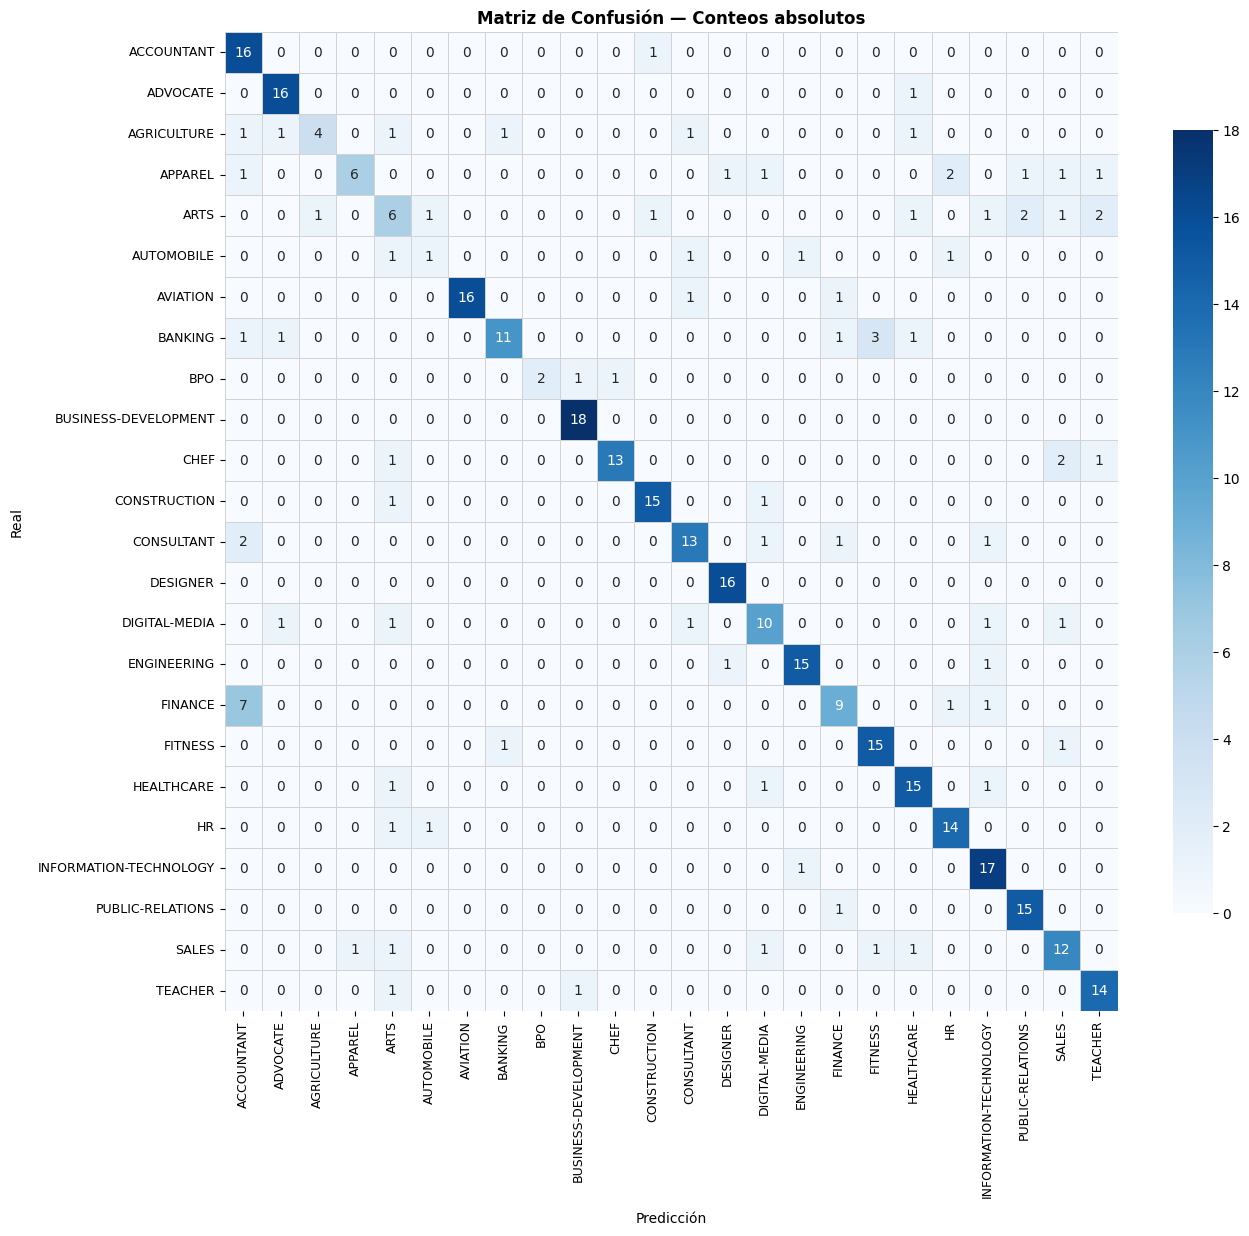

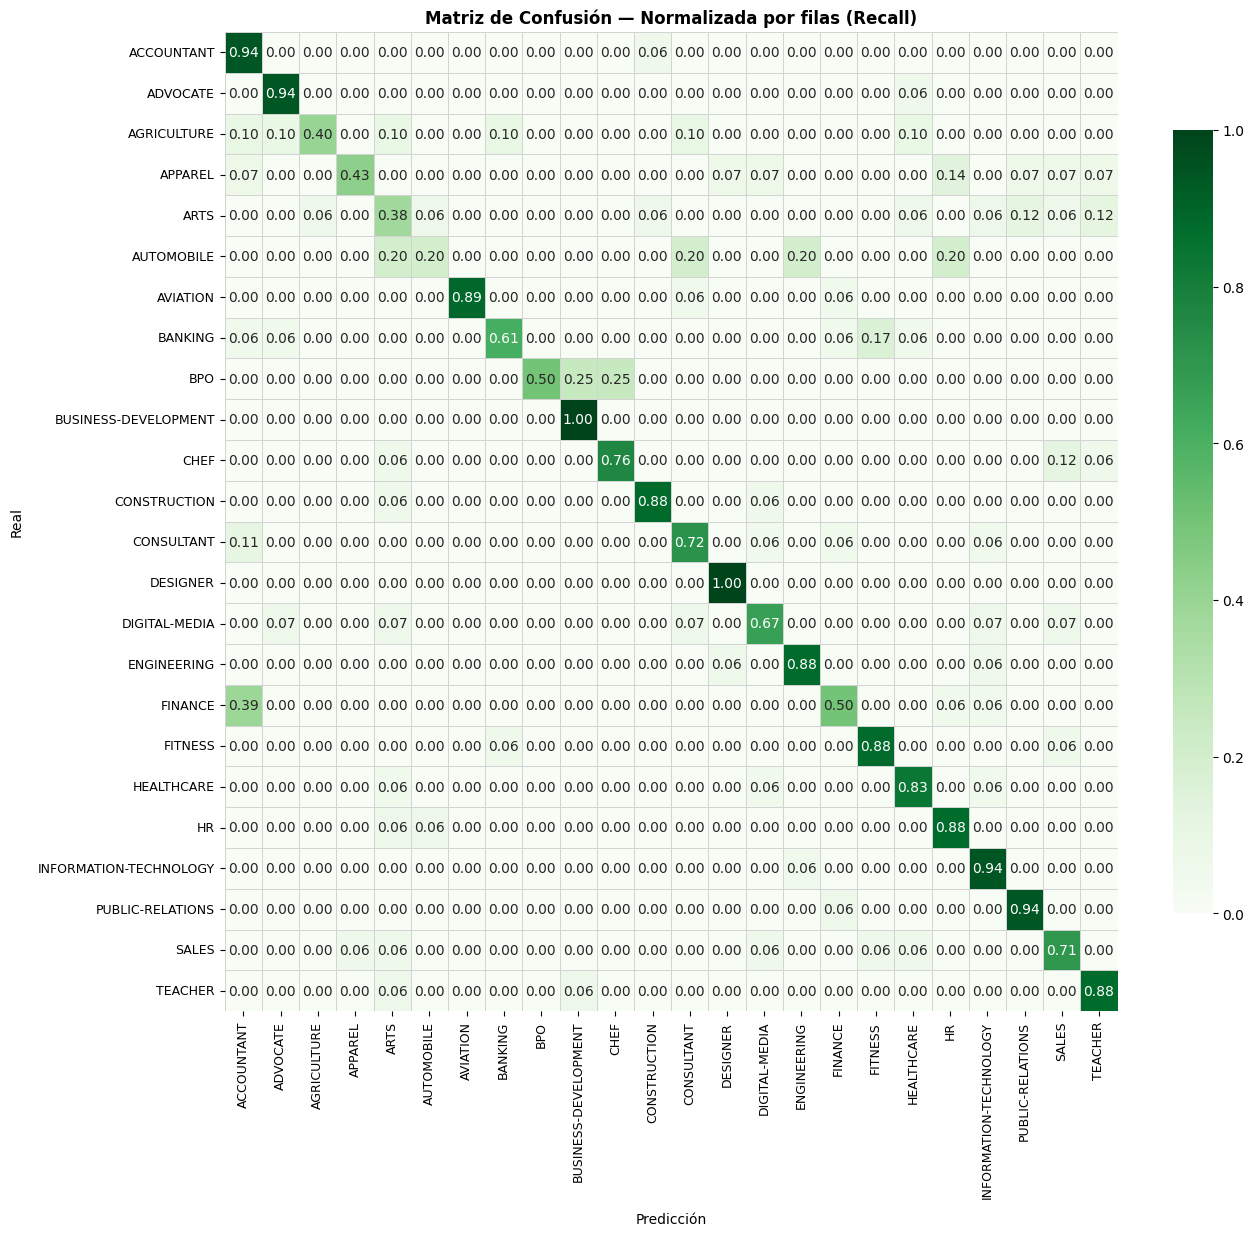


Clases con menor recall:
  AUTOMOBILE               : 0.2000
  ARTS                     : 0.3750
  AGRICULTURE              : 0.4000
  APPAREL                  : 0.4286
  BPO                      : 0.5000


In [84]:
cm = confusion_matrix(y_test, y_pred_labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizar por fila

# Tamaño dinámico según número de clases
cell_size = 0.6
fig_side  = max(12, NUM_CLASSES * cell_size)

# Figura 1: conteos absolutos
fig1, ax1 = plt.subplots(figsize=(fig_side, fig_side))
sns.heatmap(cm, ax=ax1, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='lightgray', cbar_kws={'shrink': 0.8})
ax1.set_title('Matriz de Confusión — Conteos absolutos', fontweight='bold')
ax1.set_xlabel('Predicción', labelpad=10)
ax1.set_ylabel('Real', labelpad=10)
ax1.tick_params(axis='x', rotation=90, labelsize=9)
ax1.tick_params(axis='y', rotation=0,  labelsize=9)
plt.subplots_adjust(bottom=0.2)  # aumenta el margen inferior
plt.show()

# Figura 2: normalizada
fig2, ax2 = plt.subplots(figsize=(fig_side, fig_side))
sns.heatmap(cm_norm, ax=ax2, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='lightgray', vmin=0, vmax=1,
            cbar_kws={'shrink': 0.8})
ax2.set_title('Matriz de Confusión — Normalizada por filas (Recall)', fontweight='bold')
ax2.set_xlabel('Predicción', labelpad=10)
ax2.set_ylabel('Real', labelpad=10)
ax2.tick_params(axis='x', rotation=90, labelsize=9)
ax2.tick_params(axis='y', rotation=0,  labelsize=9)
plt.subplots_adjust(bottom=0.2)  # aumenta el margen inferior
plt.show()

# Clases con peor rendimiento
per_class_recall = cm_norm.diagonal()
worst_idx = np.argsort(per_class_recall)[:5]
print("\nClases con menor recall:")
for idx in worst_idx:
    print(f"  {CLASS_NAMES[idx]:<25}: {per_class_recall[idx]:.4f}")

### 9.2 Curva ROC — One-vs-Rest por clase

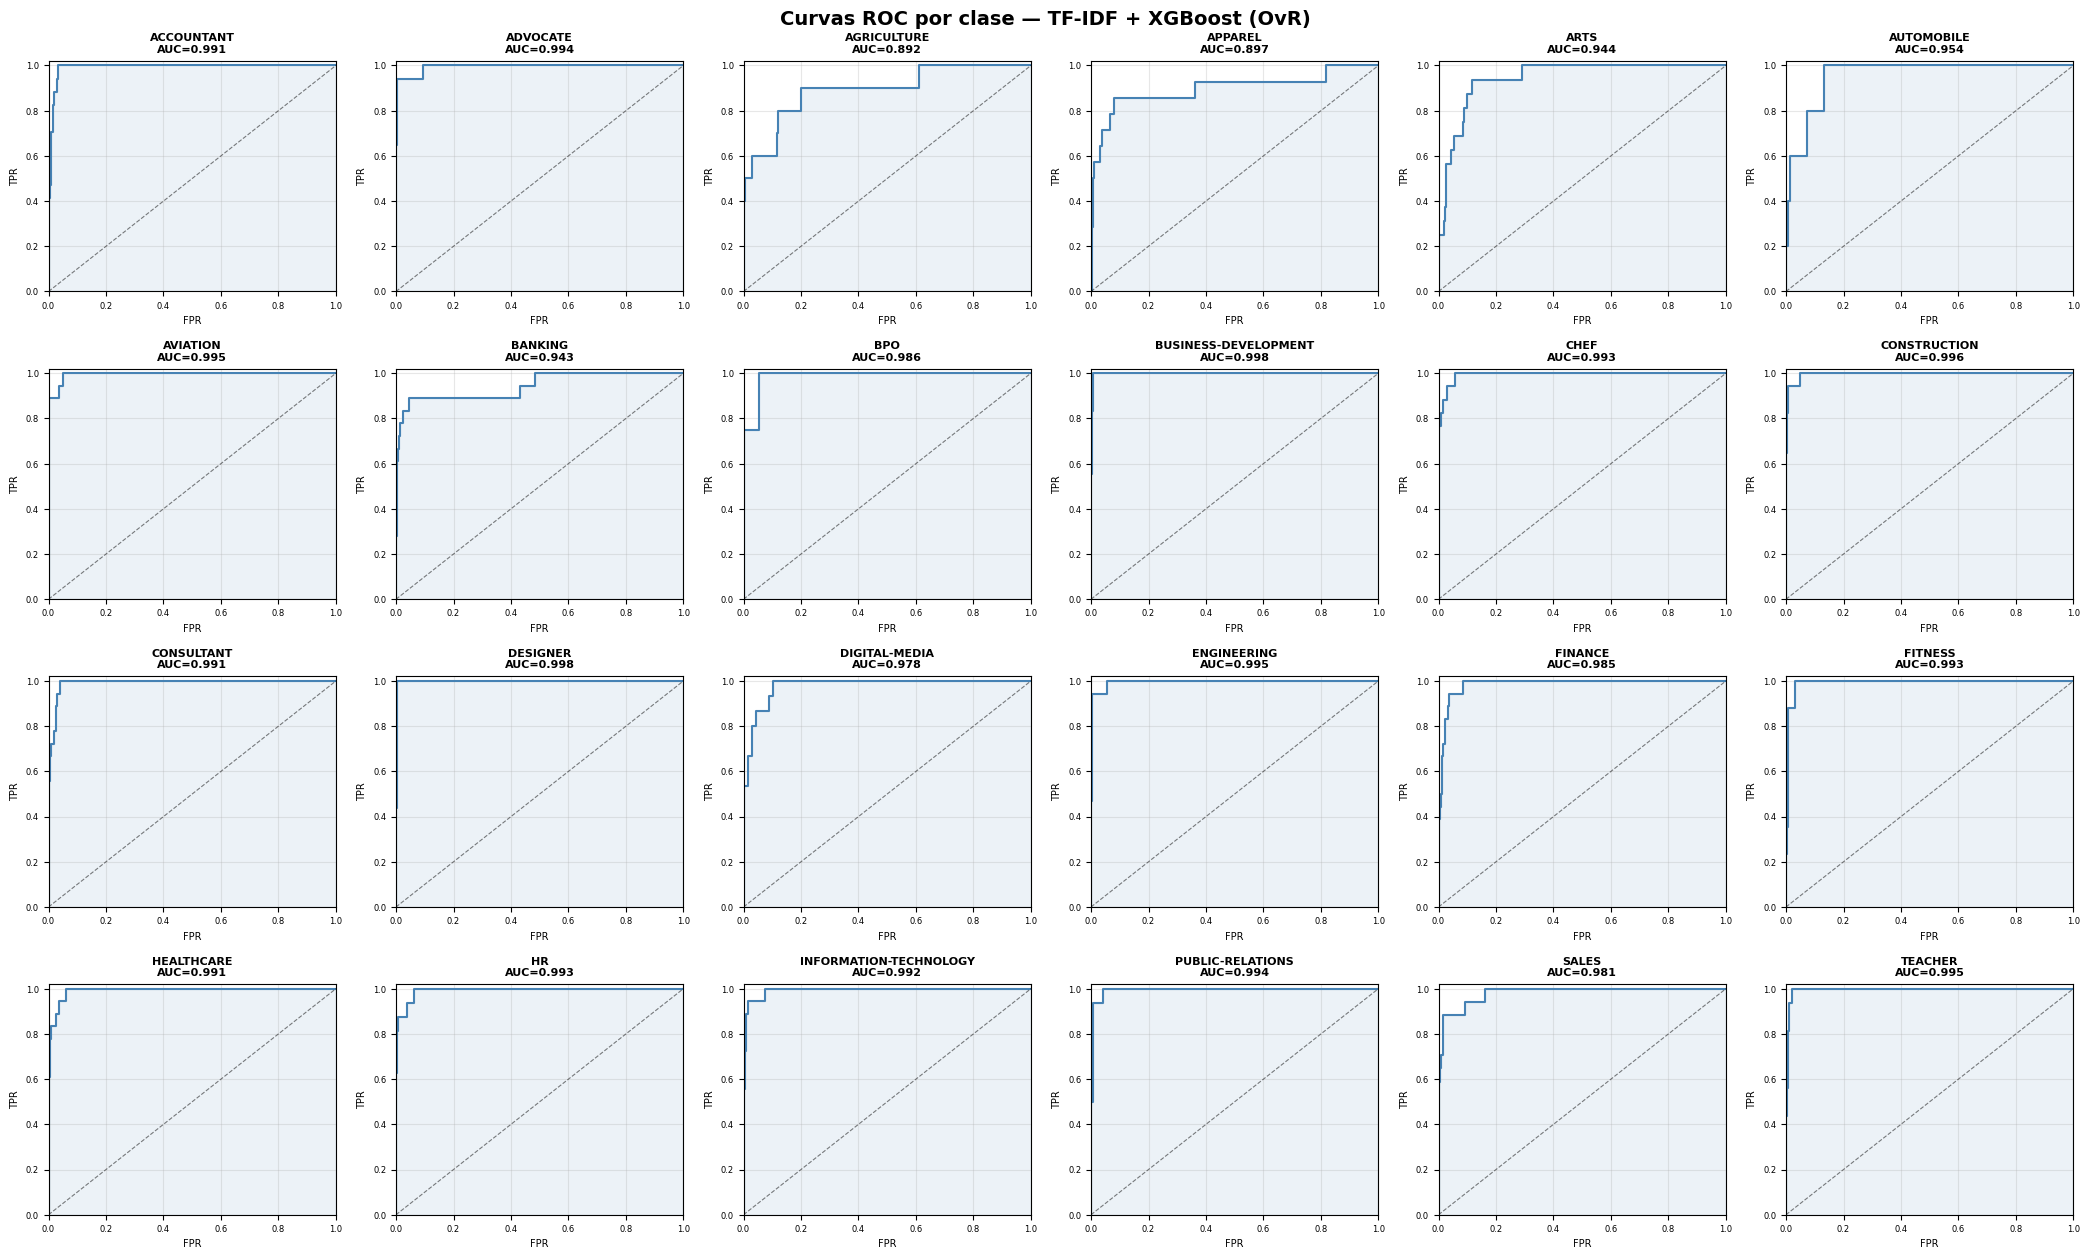

ROC-AUC micro-average : 0.9843
ROC-AUC weighted OvR  : 0.9808


In [72]:
# Binarizar etiquetas para curvas OvR
y_test_bin = label_binarize(y_test, classes=np.arange(NUM_CLASSES))

# Calcular AUC por clase
fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

# Micro-average
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# ── Plot ──────────────────────────────────────────────────────────────────────
n_cols = 6
n_rows = int(np.ceil(NUM_CLASSES / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.2))
fig.suptitle('Curvas ROC por clase — TF-IDF + XGBoost (OvR)', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i in range(NUM_CLASSES):
    ax = axes_flat[i]
    ax.plot(fpr_dict[i], tpr_dict[i], color='steelblue', lw=1.5)
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5)
    ax.fill_between(fpr_dict[i], tpr_dict[i], alpha=0.1, color='steelblue')
    ax.set_title(f"{CLASS_NAMES[i]}\nAUC={roc_auc_dict[i]:.3f}", fontsize=8, fontweight='bold')
    ax.set_xlabel('FPR', fontsize=7)
    ax.set_ylabel('TPR', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.grid(True, alpha=0.3)

# Ocultar subplots vacíos
for j in range(NUM_CLASSES, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

print(f"ROC-AUC micro-average : {roc_auc_micro:.4f}")
print(f"ROC-AUC weighted OvR  : {roc_auc_w:.4f}")

### 9.3 Curva Precision-Recall — One-vs-Rest por clase

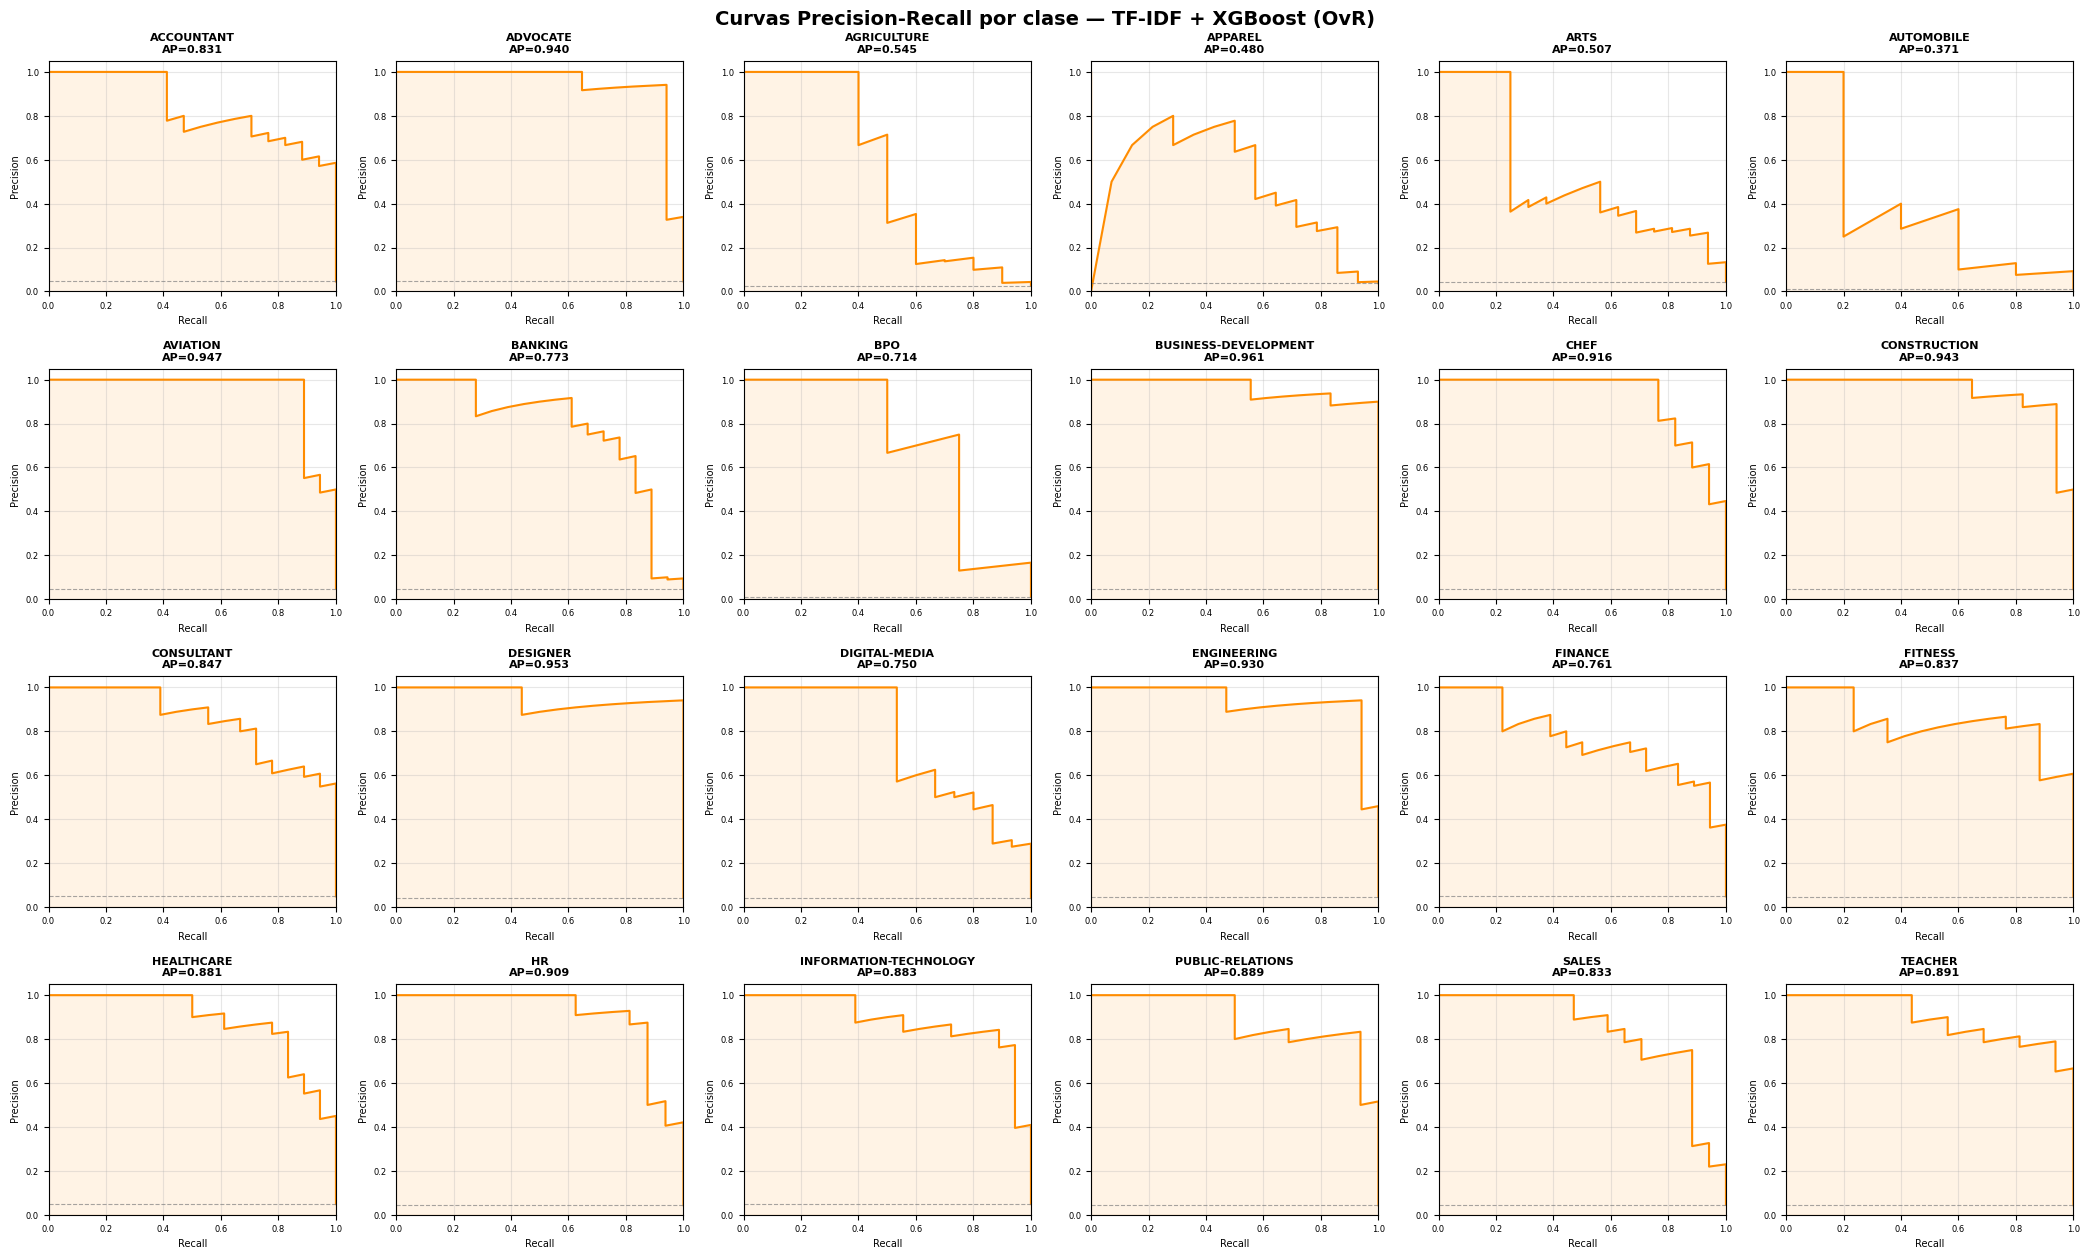

mAP (mean Average Precision): 0.8039


In [73]:
# Calcular PR por clase
prec_dict, rec_dict, pr_auc_dict = {}, {}, {}
for i in range(NUM_CLASSES):
    prec_dict[i], rec_dict[i], _ = precision_recall_curve(
        y_test_bin[:, i], y_pred_proba[:, i]
    )
    pr_auc_dict[i] = auc(rec_dict[i], prec_dict[i])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.2))
fig.suptitle('Curvas Precision-Recall por clase — TF-IDF + XGBoost (OvR)', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

# Baseline por clase (prevalencia en test)
class_prevalence = y_test_bin.mean(axis=0)

for i in range(NUM_CLASSES):
    ax = axes_flat[i]
    ax.plot(rec_dict[i], prec_dict[i], color='darkorange', lw=1.5)
    ax.fill_between(rec_dict[i], prec_dict[i], alpha=0.1, color='darkorange')
    ax.axhline(class_prevalence[i], color='gray', linestyle='--', lw=0.8, alpha=0.7)
    ax.set_title(f"{CLASS_NAMES[i]}\nAP={pr_auc_dict[i]:.3f}", fontsize=8, fontweight='bold')
    ax.set_xlabel('Recall', fontsize=7)
    ax.set_ylabel('Precision', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3)

for j in range(NUM_CLASSES, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

mean_ap = np.mean(list(pr_auc_dict.values()))
print(f"mAP (mean Average Precision): {mean_ap:.4f}")

### 9.4 F1 por clase — barplot comparativo

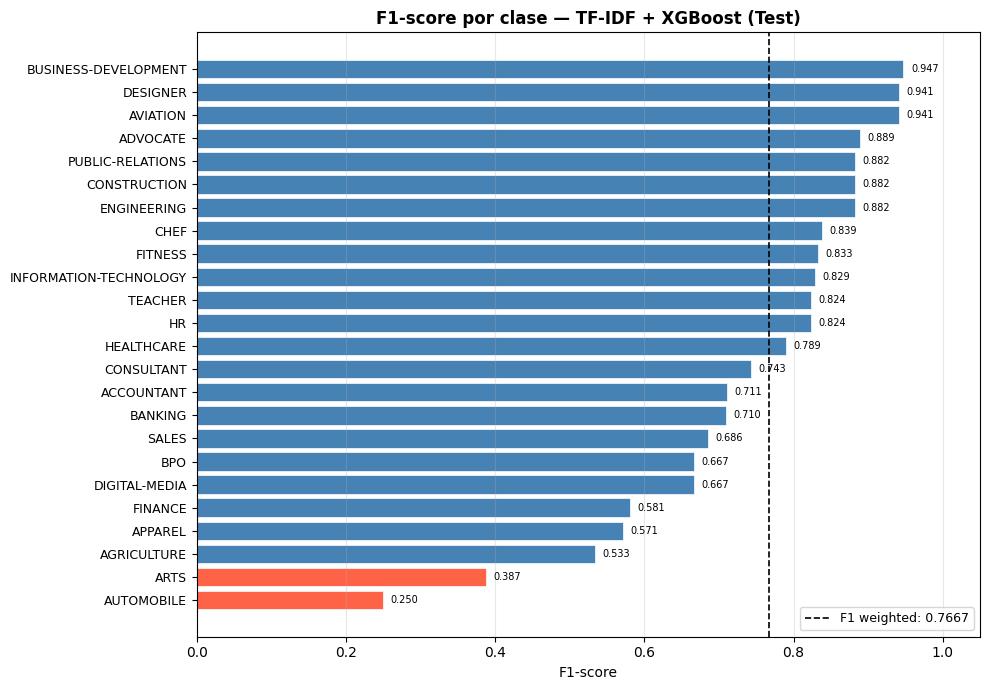

In [74]:
f1_per_class = f1_score(y_test, y_pred_labels, average=None, zero_division=0)

sorted_idx  = np.argsort(f1_per_class)
sorted_f1   = f1_per_class[sorted_idx]
sorted_names = CLASS_NAMES[sorted_idx]

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['tomato' if v < 0.5 else 'steelblue' for v in sorted_f1]
bars = ax.barh(range(NUM_CLASSES), sorted_f1, color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(NUM_CLASSES))
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel('F1-score')
ax.set_title('F1-score por clase — TF-IDF + XGBoost (Test)', fontweight='bold')
ax.axvline(f1_w, color='black', linestyle='--', lw=1.2, label=f'F1 weighted: {f1_w:.4f}')
ax.set_xlim([0, 1.05])
ax.legend(fontsize=9)
ax.grid(True, axis='x', alpha=0.3)

# Anotar valores
for i, (bar, val) in enumerate(zip(bars, sorted_f1)):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7)

plt.tight_layout()
plt.show()

### 9.5 Importancia de features (Top términos TF-IDF)

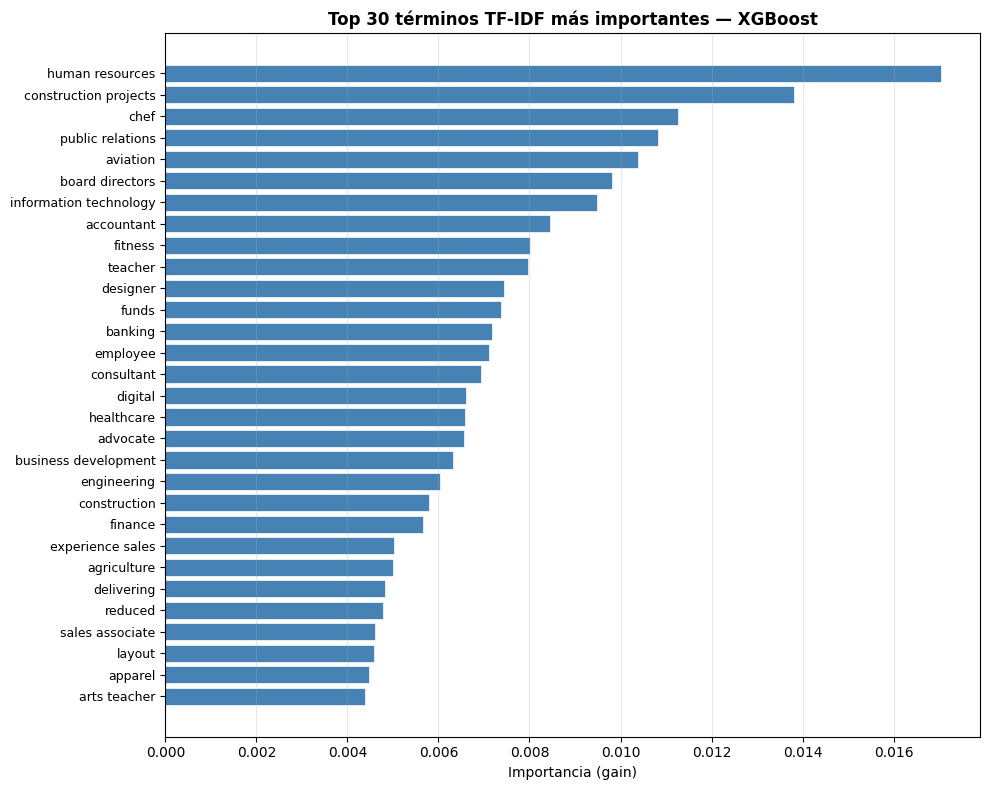

In [75]:
# Feature importance del modelo XGBoost
importances = model.feature_importances_
feature_names = np.array(tfidf.get_feature_names_out())

top_n = 30
top_idx   = np.argsort(importances)[::-1][:top_n]
top_names = feature_names[top_idx]
top_vals  = importances[top_idx]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(top_n), top_vals[::-1], color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names[::-1], fontsize=9)
ax.set_xlabel('Importancia (gain)')
ax.set_title(f'Top {top_n} términos TF-IDF más importantes — XGBoost', fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 10. Guardar modelo y métricas

In [76]:
# ── Guardar modelo XGBoost ────────────────────────────────────────────────────
model.save_model(MODEL_PATH)
print(f"Modelo guardado en: {MODEL_PATH}")

# ── Guardar vectorizador TF-IDF ───────────────────────────────────────────────
with open(TFIDF_PATH, 'wb') as f:
    pickle.dump(tfidf, f)
print(f"TF-IDF guardado en : {TFIDF_PATH}")

Modelo guardado en: /home/alejo/DeepLearning/miniproyecto3/models/tfidf_xgboost.json
TF-IDF guardado en : /home/alejo/DeepLearning/miniproyecto3/models/tfidf_xgboost_tfidf.pkl


In [77]:
# ── Construir y guardar JSON de métricas ──────────────────────────────────────
report_dict = classification_report(
    y_test, y_pred_labels,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

# TFIDF_PARAMS tiene dtype=np.float32 que no es serializable — convertir a string
tfidf_params_serializable = {
    k: str(v) if isinstance(v, type) else v
    for k, v in TFIDF_PARAMS.items()
}

metrics_payload = {
    "model_name"   : "TF-IDF + XGBoost",
    "notebook"     : "02_Model_TFIDF_XGBoost.ipynb",
    "timestamp"    : datetime.now().isoformat(),
    "hyperparameters": {
        "tfidf": tfidf_params_serializable,
        "xgboost": {
            k: v for k, v in XGB_PARAMS.items()
            if k not in ['eval_metric', 'objective']
        },
        "best_iteration": int(best_round),
        "device": DEVICE,
    },
    "metrics": {
        "accuracy"              : float(acc),
        "precision_weighted"    : float(prec_w),
        "recall_weighted"       : float(rec_w),
        "f1_weighted"           : float(f1_w),
        "roc_auc_ovr_weighted"  : float(roc_auc_w),
        "roc_auc_micro"         : float(roc_auc_micro),
        "mean_average_precision": float(mean_ap),
    },
    "per_class": {
        name: {
            "precision" : float(report_dict[name]['precision']),
            "recall"    : float(report_dict[name]['recall']),
            "f1"        : float(report_dict[name]['f1-score']),
            "support"   : int(report_dict[name]['support']),
            "roc_auc"   : float(roc_auc_dict[i]),
            "pr_auc"    : float(pr_auc_dict[i]),
        }
        for i, name in enumerate(CLASS_NAMES)
    },
    "training_time_seconds": float(training_time),
    "tfidf_time_seconds"   : float(tfidf_time),
    "data_sizes": {
        "train": int(len(y_train)),
        "val"  : int(len(y_val)),
        "test" : int(len(y_test)),
    }
}

with open(METRICS_PATH, 'w') as f:
    json.dump(metrics_payload, f, indent=2)

print(f"Métricas guardadas en: {METRICS_PATH}")
print()
print("Resumen final:")
for k, v in metrics_payload['metrics'].items():
    print(f"  {k:<30}: {v:.4f}")

Métricas guardadas en: /home/alejo/DeepLearning/miniproyecto3/artifacts/metrics/tfidf_xgboost.json

Resumen final:
  accuracy                      : 0.7748
  precision_weighted            : 0.7816
  recall_weighted               : 0.7748
  f1_weighted                   : 0.7667
  roc_auc_ovr_weighted          : 0.9808
  roc_auc_micro                 : 0.9843
  mean_average_precision        : 0.8039


---
## 11. Resumen del modelo

| Componente | Detalle |
|---|---|
| Vectorizador | TF-IDF, max_features=50k, unigramas+bigramas, sublinear_tf |
| Clasificador | XGBoost multiclase (`multi:softprob`), early stopping |
| Desbalance | `sample_weight` balanceado en train |
| Validación | eval_set con val, early stopping patience=20 rondas |
| Evaluación | Test set — una sola evaluación final |
| Métricas | Todas `weighted` por desbalance 5.45x |

**Ventaja de TF-IDF vs embeddings:** usa el texto completo (584 palabras promedio), mientras que CNN-1D y BiLSTM truncan a MAX_LEN=100 tokens (~17% del contenido real). Esto puede darle una ventaja injusta al baseline — tener en cuenta en el análisis crítico final.